# Iterative SLSQP — Refactored
Uses `dvfopt` for all correction logic. Same test cases as `slsqp-iterative.ipynb`.

In [ ]:
import numpy as np
from dvfopt.laplacian import sliceToSlice3DLaplacian
from dvfopt import iterative_with_jacobians2, jacobian_det2D
from dvfopt.viz import plot_deformations, plot_grid_before_after, plot_initial_deformation, run_lapl_and_correction

# Test cases
## Standard run

[Laplacian] deformation shape: (3, 1, 10, 10)


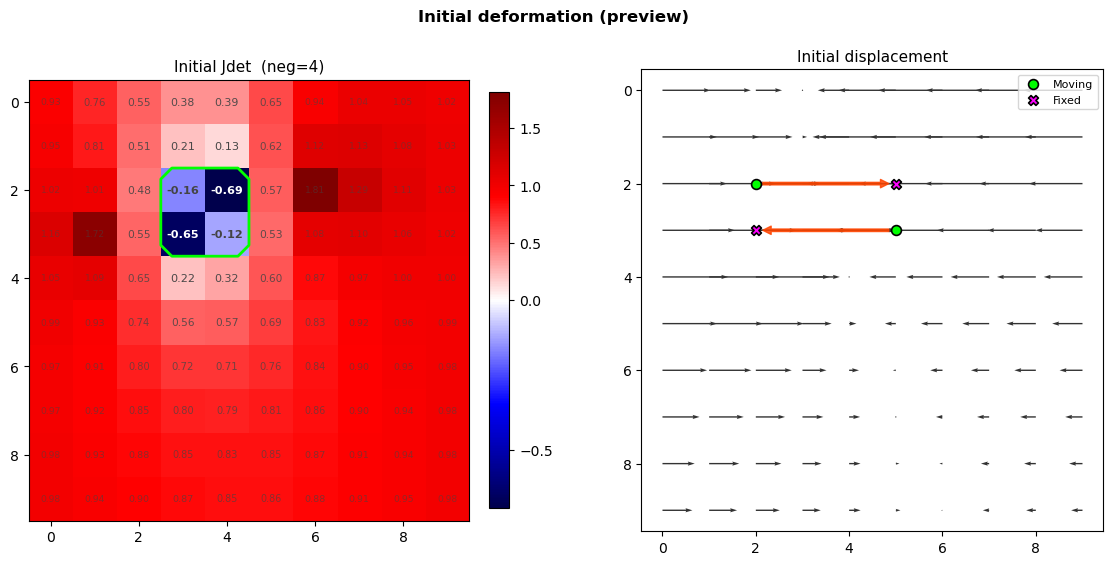

[init] Grid 10x10  |  threshold=0.01  |  method=SLSQP
[init] Neg-Jdet pixels: 4  |  min Jdet: -0.693885
[done] All Jdet > threshold after iter 1
[iter    1]  fix (  2,  4)  win   9  neg_jdet     0  min_jdet +0.010000  L2 1.1844  sub-iters 1


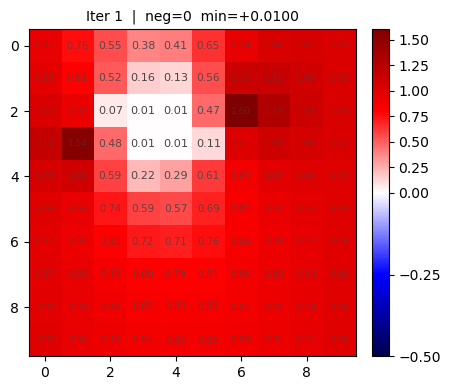

[done] All Jdet > threshold after iter 1

  SUMMARY  (SLSQP)
------------------------------------------------------------
  Grid size        : 10 x 10
  Iterations       : 1
  Neg-Jdet      4 ->     0
  Min Jdet  -0.693885 -> +0.010000
  L2 error         : 1.184403
  Time             : 6.75s
            x-disp min  x-disp max  y-disp min  y-disp max    Jdet min    Jdet max  neg Jdet
--------------------------------------------------------------------------------------------
   initial     -2.9997      2.9997      0.0000      0.0000     -0.6939      1.8097         4
 corrected     -2.6307      2.6437     -0.3771      0.3879      0.0100      1.6029         0


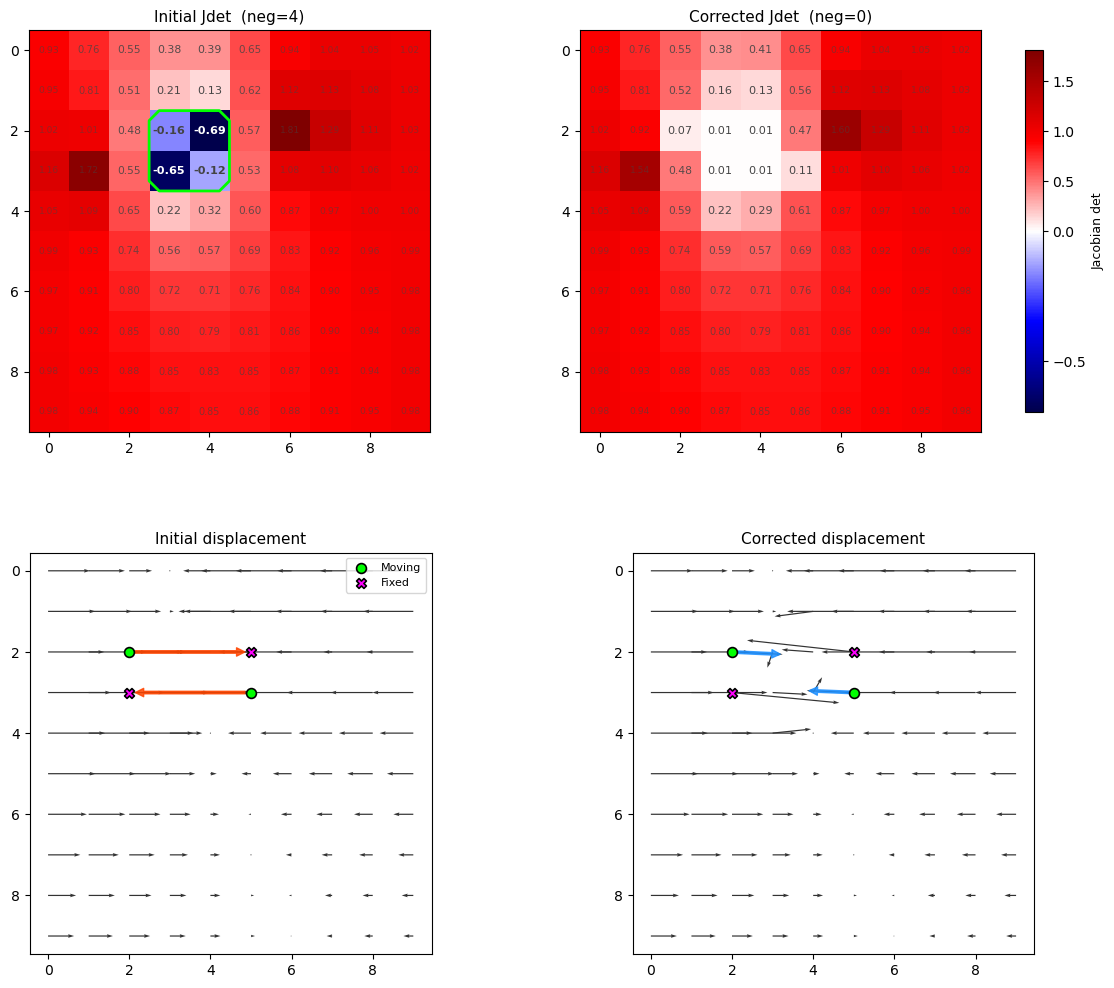

In [2]:
msample = np.array([
    [0, 2, 2],
    [0, 3, 5],
])
fsample = np.array([
    [0, 2, 5],
    [0, 3, 2],
])

fixed_sample = np.zeros((1, 10, 10)) # depth, rows, cols

run_lapl_and_correction(fixed_sample, msample, fsample, plot_every=1)

## Long runtime

[Laplacian] deformation shape: (3, 1, 10, 10)


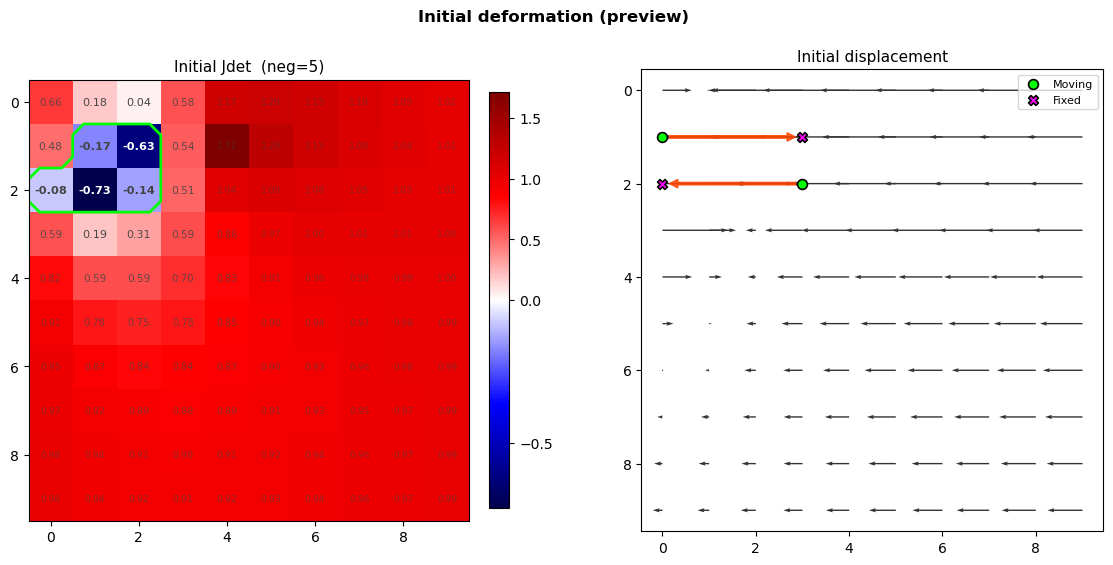

[init] Grid 10x10  |  threshold=0.01  |  method=SLSQP
[init] Neg-Jdet pixels: 5  |  min Jdet: -0.730373
[done] All Jdet > threshold after iter 1
[iter    1]  fix (  2,  1)  win   9  neg_jdet     0  min_jdet +0.010000  L2 1.2135  sub-iters 1


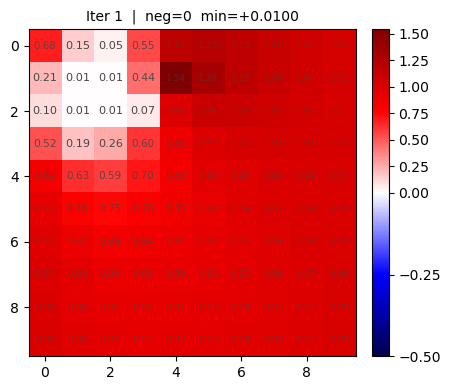

[done] All Jdet > threshold after iter 1

  SUMMARY  (SLSQP)
------------------------------------------------------------
  Grid size        : 10 x 10
  Iterations       : 1
  Neg-Jdet      5 ->     0
  Min Jdet  -0.730373 -> +0.010000
  L2 error         : 1.213457
  Time             : 6.95s
            x-disp min  x-disp max  y-disp min  y-disp max    Jdet min    Jdet max  neg Jdet
--------------------------------------------------------------------------------------------
   initial     -2.9998      2.9998      0.0000      0.0000     -0.7304      1.7091         5
 corrected     -2.7093      2.5551     -0.3954      0.3723      0.0100      1.5396         0


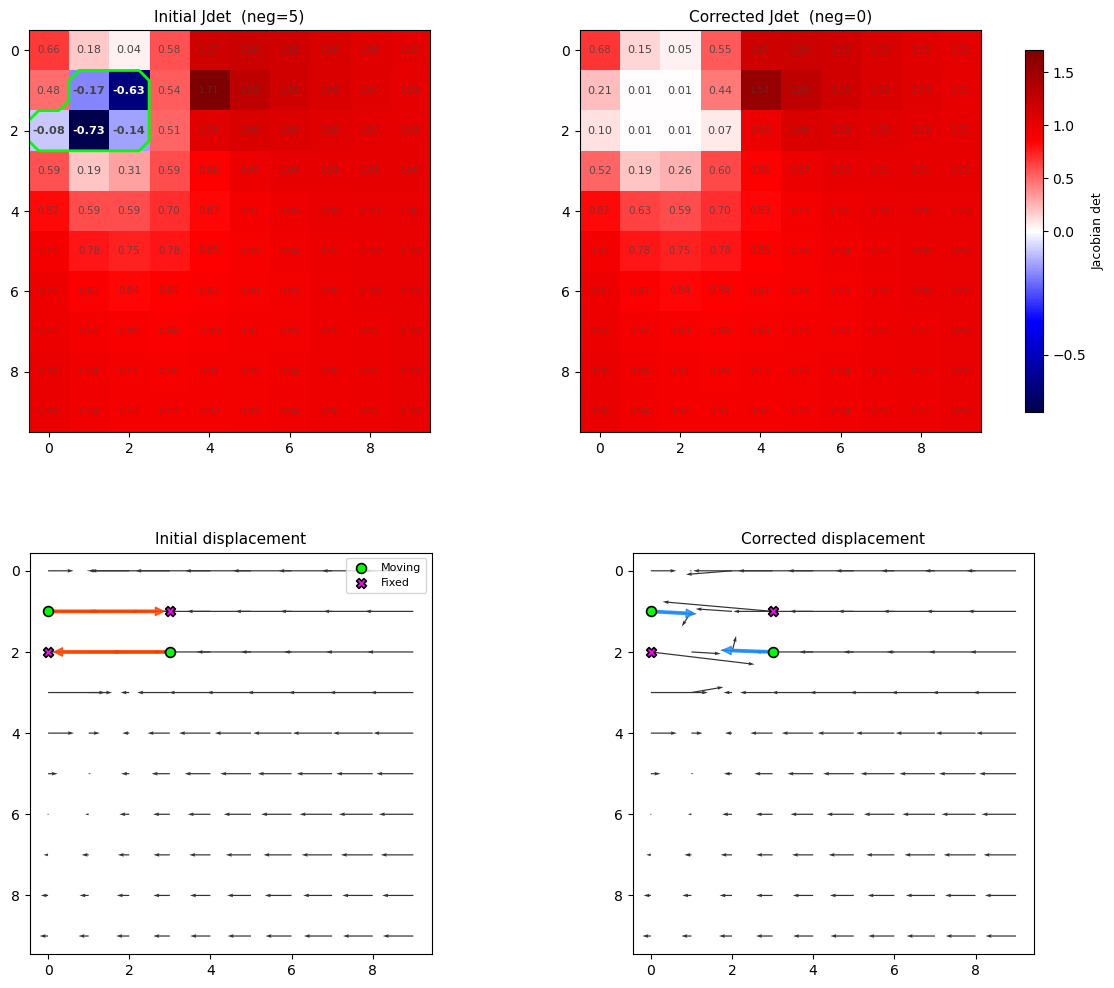

In [3]:
msample = np.array([
    [0, 1, 0],
    [0, 2, 3],
])
fsample = np.array([
    [0, 1, 3],
    [0, 2, 0],
])

fixed_sample = np.zeros((1, 10, 10))

run_lapl_and_correction(fixed_sample, msample, fsample, plot_every=1)

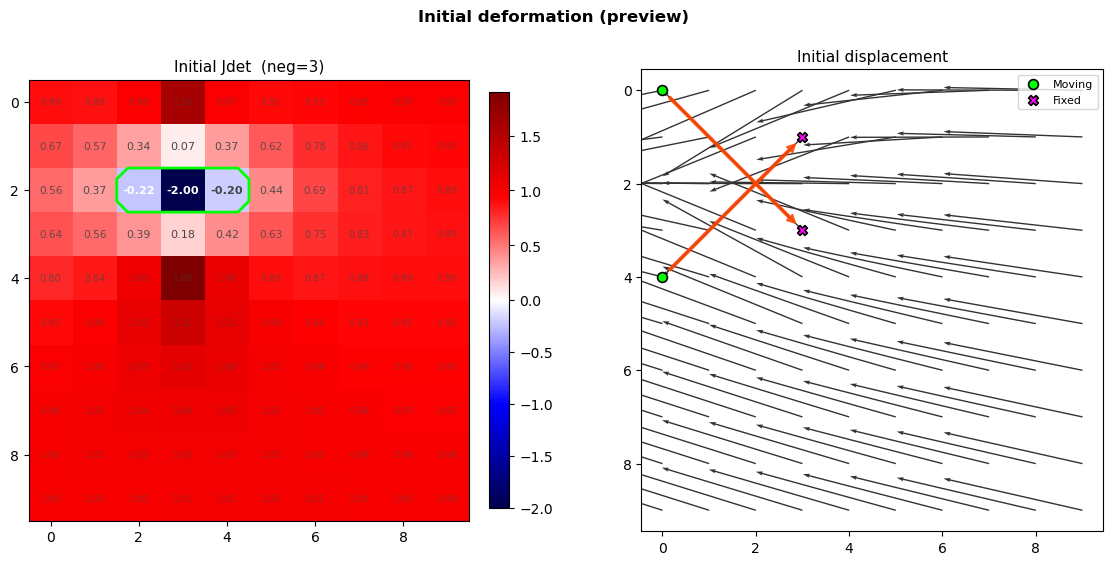

[init] Grid 10x10  |  threshold=0.01  |  method=SLSQP
[init] Neg-Jdet pixels: 3  |  min Jdet: -2.003395
[done] All Jdet > threshold after iter 1
[iter    1]  fix (  2,  3)  win   9  neg_jdet     0  min_jdet +0.010000  L2 1.5815  sub-iters 1


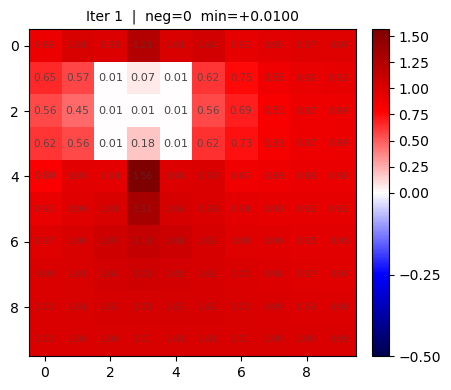

[done] All Jdet > threshold after iter 1

  SUMMARY  (SLSQP)
------------------------------------------------------------
  Grid size        : 10 x 10
  Iterations       : 1
  Neg-Jdet      3 ->     0
  Min Jdet  -2.003395 -> +0.010000
  L2 error         : 1.581503
  Time             : 6.14s
            x-disp min  x-disp max  y-disp min  y-disp max    Jdet min    Jdet max  neg Jdet
--------------------------------------------------------------------------------------------
   initial     -3.0137     -2.9773     -2.9998      2.9998     -2.0034      1.8931         3
 corrected     -4.0065     -1.9960     -2.8858      2.8683      0.0100      1.5650         0


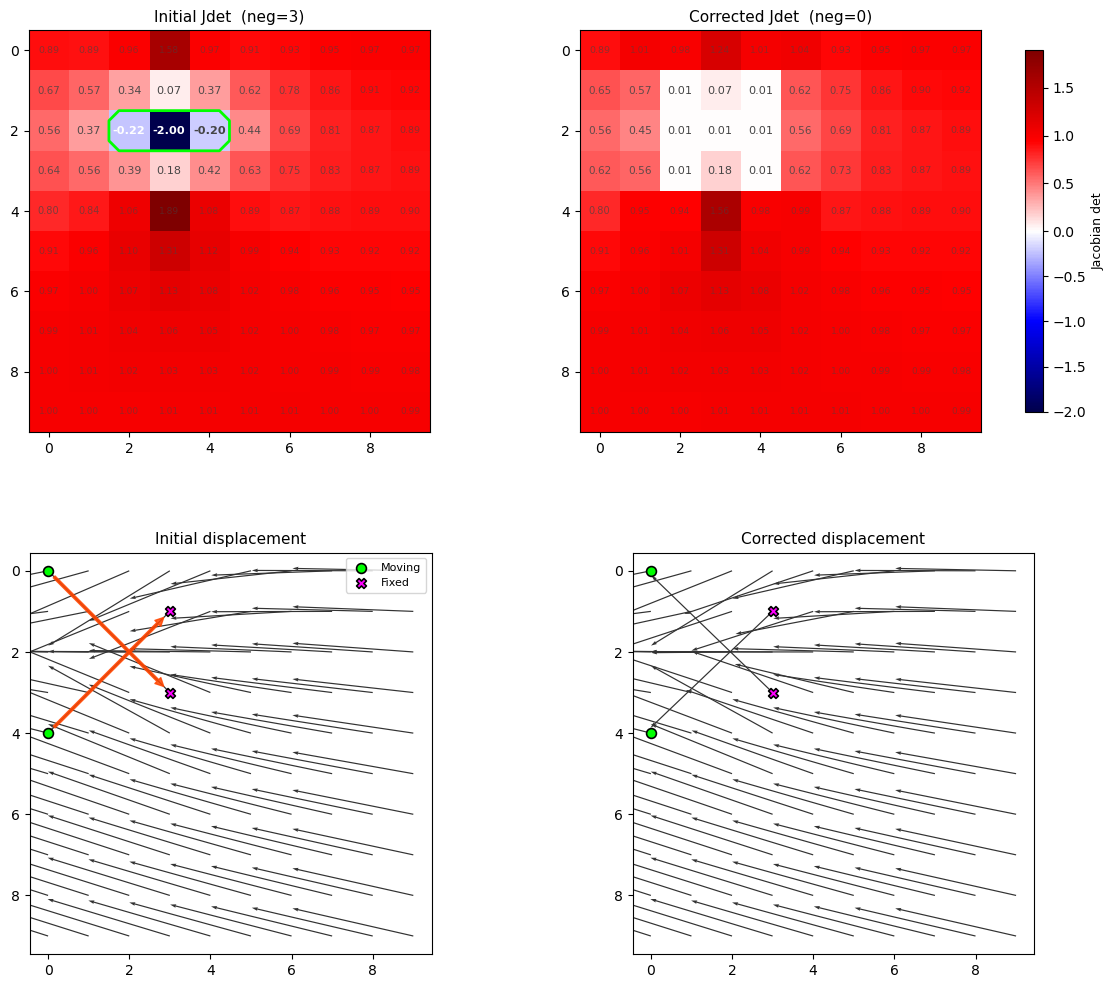

In [ ]:
msample = np.array([
    [0, 0, 0],
    [0, 4, 0],
])
fsample = np.array([
    [0, 3, 3],
    [0, 1, 3],
])

fixed_sample = np.zeros((1, 10, 10))
deformation_i, A, Zd, Yd, Xd = laplacian.sliceToSlice3DLaplacian(fixed_sample, msample, fsample)
plot_initial_deformation(deformation_i, msample, fsample)
phi_corrected = iterative_with_jacobians2(deformation_i, methodName='SLSQP', plot_every=1)
plot_deformations(msample, fsample, deformation_i, phi_corrected)
plot_grid_before_after(deformation_i, phi_corrected)

[Laplacian] deformation shape: (3, 1, 10, 10)


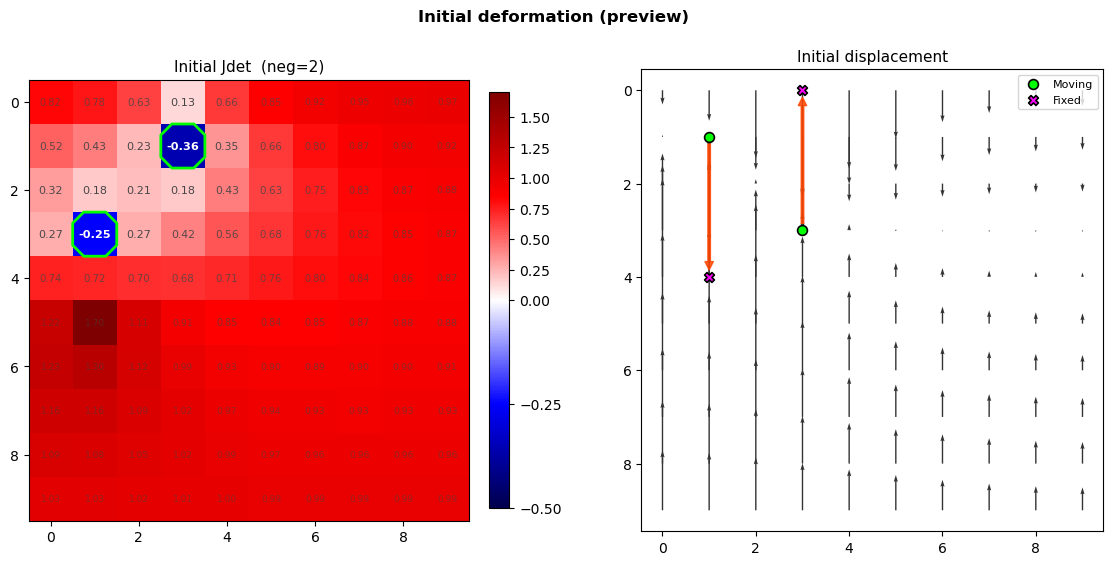

[init] Grid 10x10  |  threshold=0.01  |  method=SLSQP
[init] Neg-Jdet pixels: 2  |  min Jdet: -0.356906
[done] All Jdet > threshold after iter 1
[iter    1]  fix (  1,  3)  win   9  neg_jdet     0  min_jdet +0.010000  L2 0.6256  sub-iters 1


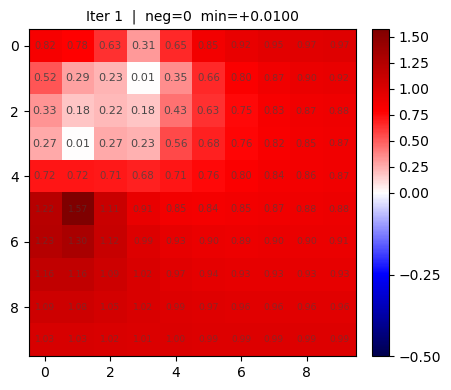

[done] All Jdet > threshold after iter 1

  SUMMARY  (SLSQP)
------------------------------------------------------------
  Grid size        : 10 x 10
  Iterations       : 1
  Neg-Jdet      2 ->     0
  Min Jdet  -0.356906 -> +0.010000
  L2 error         : 0.625637
  Time             : 7.83s
            x-disp min  x-disp max  y-disp min  y-disp max    Jdet min    Jdet max  neg Jdet
--------------------------------------------------------------------------------------------
   initial      0.0000      0.0000     -2.9997      2.9997     -0.3569      1.7010         2
 corrected     -0.0696      0.0671     -2.7569      2.6426      0.0100      1.5714         0


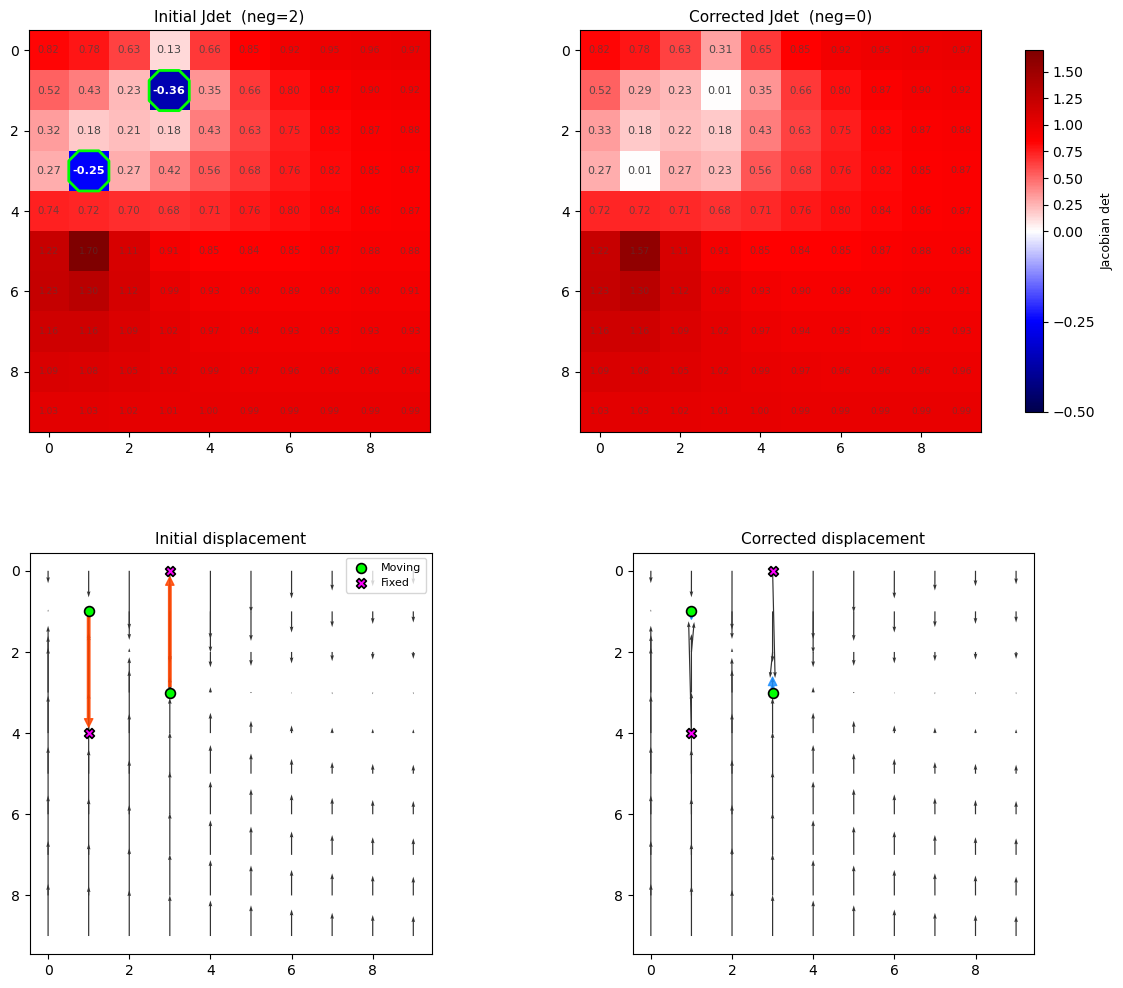

In [5]:
msample = np.array([
    [0, 1, 1],
    [0, 3, 3],
])
fsample = np.array([
    [0, 4, 1],
    [0, 0, 3],
])

fixed_sample = np.zeros((1, 10, 10))
run_lapl_and_correction(fixed_sample, msample, fsample, plot_every=1)

[Laplacian] deformation shape: (3, 1, 10, 10)


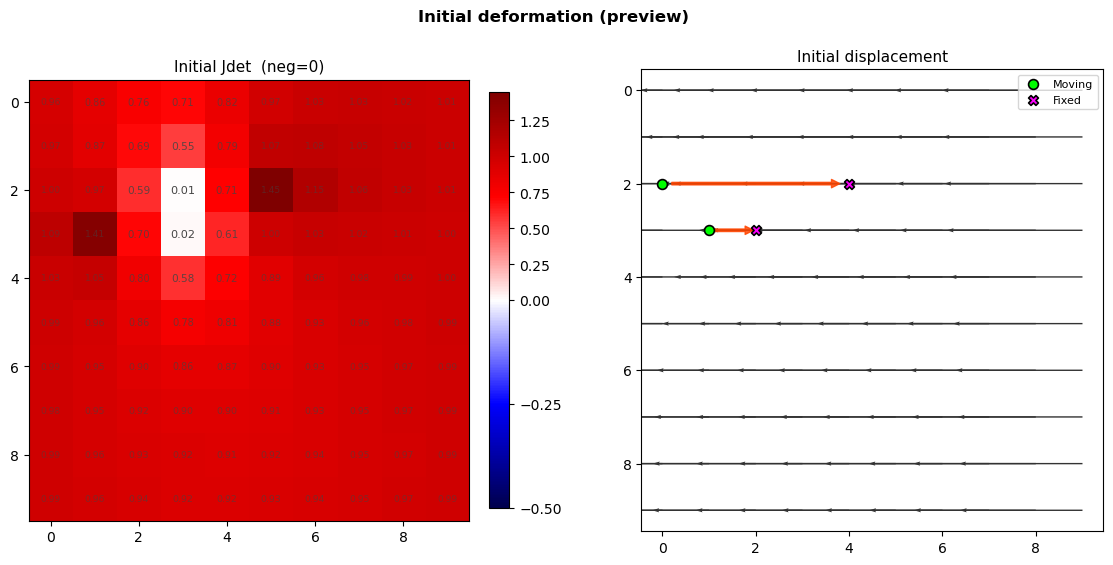

[init] Grid 10x10  |  threshold=0.01  |  method=SLSQP
[init] Neg-Jdet pixels: 0  |  min Jdet: 0.008381
[done] All Jdet > threshold after iter 1
[iter    1]  fix (  2,  3)  win   9  neg_jdet     0  min_jdet +0.010000  L2 0.0022  sub-iters 1


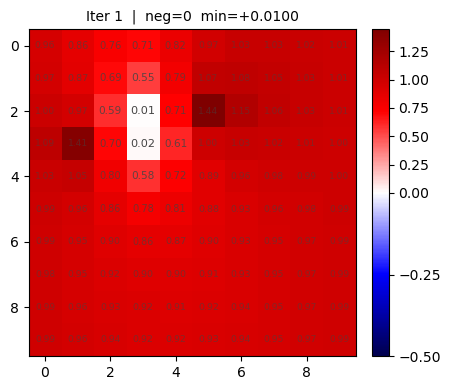

[done] All Jdet > threshold after iter 1

  SUMMARY  (SLSQP)
------------------------------------------------------------
  Grid size        : 10 x 10
  Iterations       : 1
  Neg-Jdet      0 ->     0
  Min Jdet  +0.008381 -> +0.010000
  L2 error         : 0.002214
  Time             : 5.23s
            x-disp min  x-disp max  y-disp min  y-disp max    Jdet min    Jdet max  neg Jdet
--------------------------------------------------------------------------------------------
   initial     -3.9997     -0.9999      0.0000      0.0000      0.0084      1.4455         0
 corrected     -3.9982     -0.9999     -0.0004      0.0004      0.0100      1.4447         0


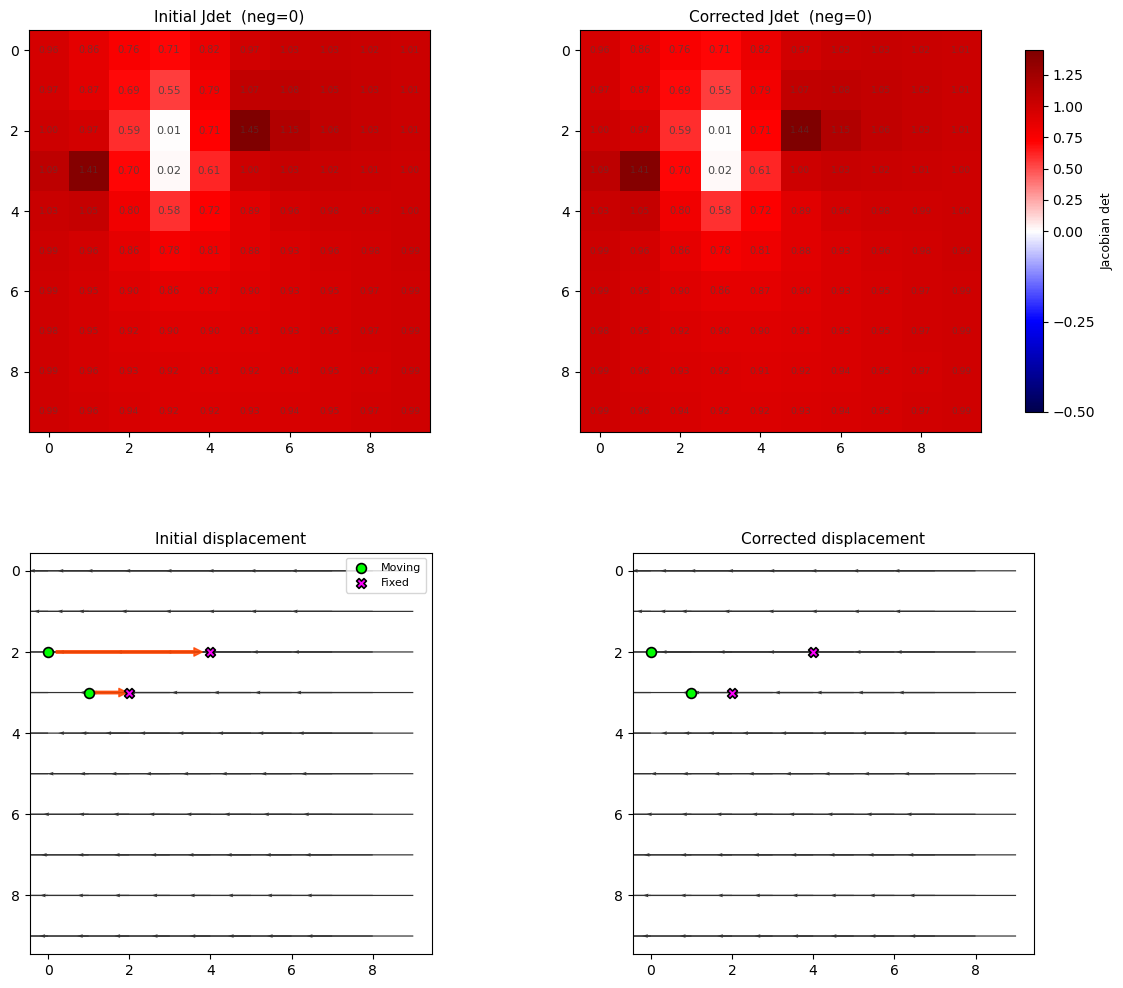

In [6]:
msample = np.array([
    [0, 2, 0],
    [0, 3, 1],
])
fsample = np.array([
    [0, 2, 4],
    [0, 3, 2],
])

fixed_sample = np.zeros((1, 10, 10))
run_lapl_and_correction(fixed_sample, msample, fsample, plot_every=1)

## Some more testcases

[Laplacian] deformation shape: (3, 1, 20, 40)


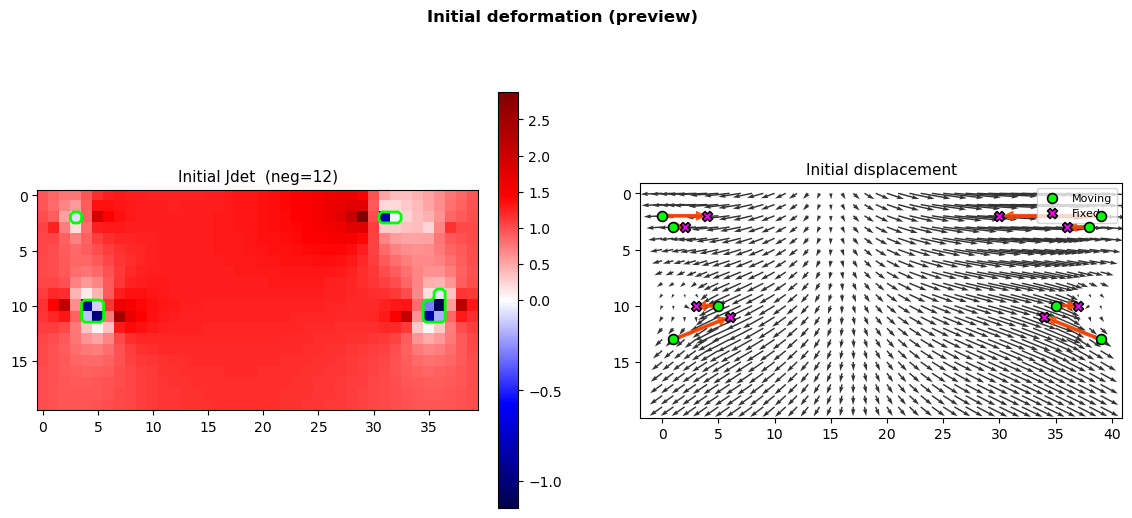

[init] Grid 20x40  |  threshold=0.01  |  method=SLSQP
[init] Neg-Jdet pixels: 12  |  min Jdet: -1.150262
[iter    1]  fix ( 10, 36)  win   9  neg_jdet     7  min_jdet -0.958856  L2 1.3021  sub-iters 1


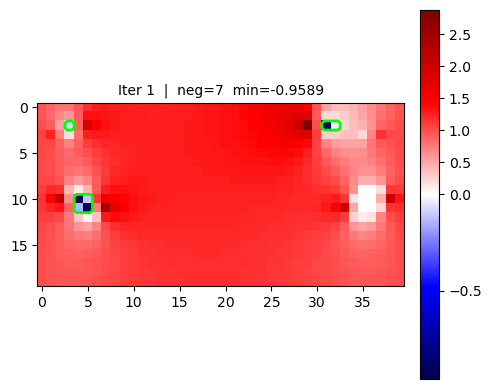

[iter    2]  fix ( 11,  5)  win   9  neg_jdet     3  min_jdet -0.869870  L2 1.7067  sub-iters 1


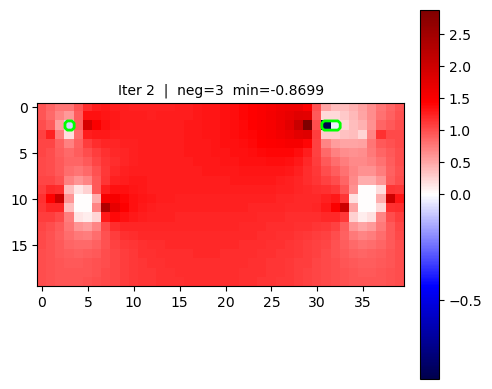

[iter    3]  fix (  2, 31)  win   9  neg_jdet     1  min_jdet -0.071163  L2 2.0222  sub-iters 1


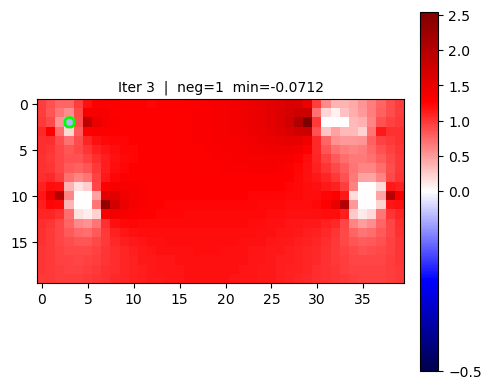

[iter    4]  fix (  2,  3)  win   9  neg_jdet     0  min_jdet +0.009982  L2 2.0251  sub-iters 1


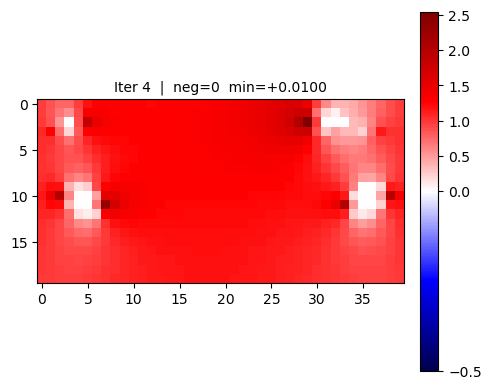

[done] All Jdet > threshold after iter 5
[iter    5]  fix (  9, 35)  win   9  neg_jdet     0  min_jdet +0.010000  L2 2.0251  sub-iters 1


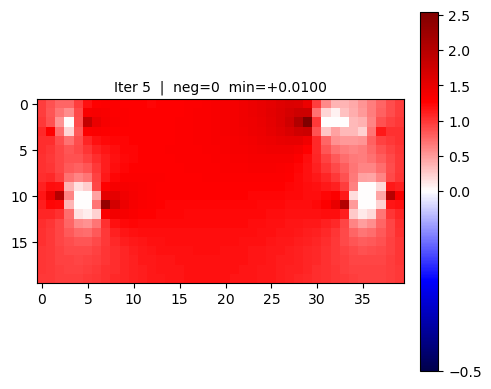

[done] All Jdet > threshold after iter 5

  SUMMARY  (SLSQP)
------------------------------------------------------------
  Grid size        : 20 x 40
  Iterations       : 5
  Neg-Jdet     12 ->     0
  Min Jdet  -1.150262 -> +0.010000
  L2 error         : 2.025141
  Time             : 35.86s
            x-disp min  x-disp max  y-disp min  y-disp max    Jdet min    Jdet max  neg Jdet
--------------------------------------------------------------------------------------------
   initial     -4.9993      8.9987      0.0000      1.9988     -1.1503      2.8771        12
 corrected     -4.7552      8.4604     -0.4083      2.1798      0.0100      2.5435         0


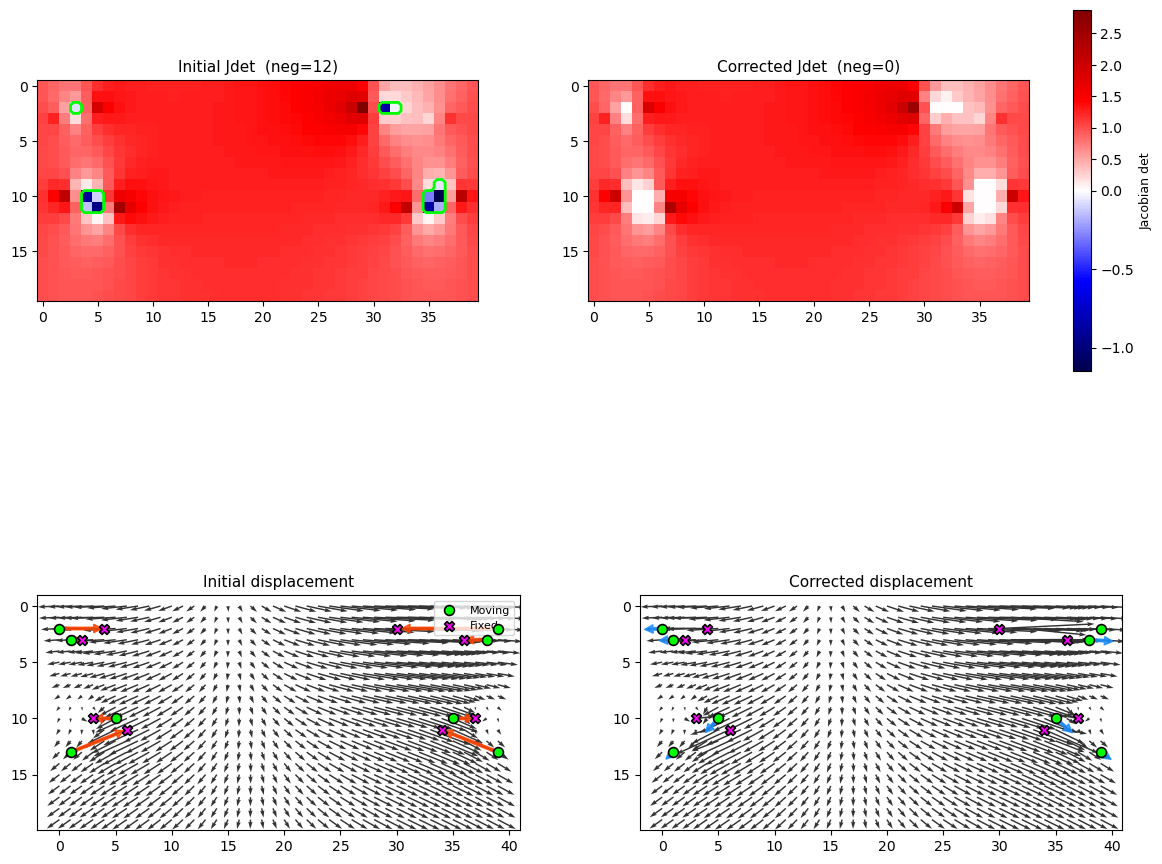

In [7]:
msample = np.array([
    [0, 2, 0],
    [0, 3, 1],
    [0, 10, 5],
    [0, 13, 1],
    [0, 2, 39],
    [0, 3, 38],
    [0, 10, 35],
    [0, 13, 39],
])
fsample = np.array([
    [0, 2, 4],
    [0, 3, 2],
    [0, 10, 3],
    [0, 11, 6],
    [0, 2, 30],
    [0, 3, 36],
    [0, 10, 37],
    [0, 11, 34]
])

fixed_sample = np.zeros((1, 20, 40))

run_lapl_and_correction(fixed_sample, msample, fsample, plot_every=1)

## This one takes really long

[Laplacian] deformation shape: (3, 1, 20, 40)


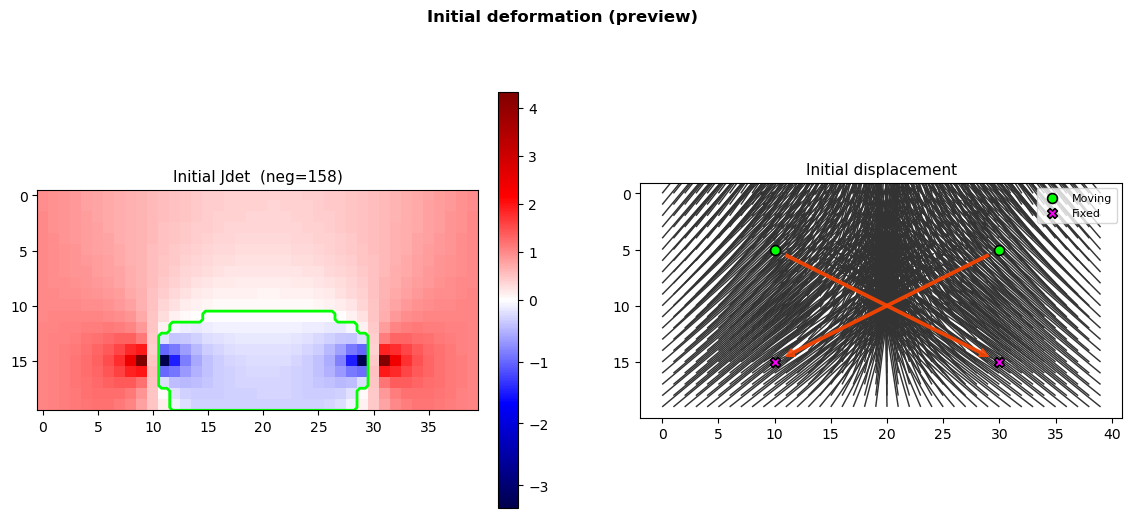

[init] Grid 20x40  |  threshold=0.01  |  method=SLSQP
[init] Neg-Jdet pixels: 158  |  min Jdet: -3.369923
[iter    1]  fix ( 15, 11)  win  19  neg_jdet    84  min_jdet -3.309977  L2 9.3122  sub-iters 6


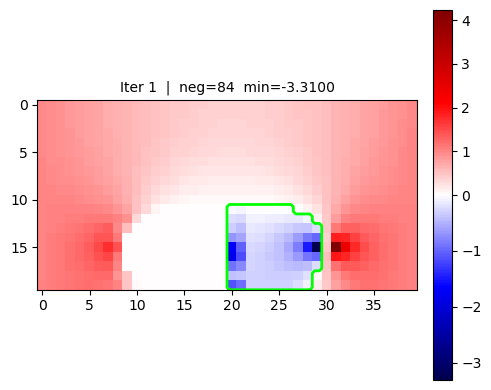

In [ ]:
msample = np.array([
    [0, 5, 10],
    [0, 5, 30],
])
fsample = np.array([
    [0, 15, 30],
    [0, 15, 10],
])

fixed_sample = np.zeros((1, 20, 40))

run_lapl_and_correction(fixed_sample, msample, fsample, plot_every=1)

In [ ]:
msample = np.array([
    [0, 5, 10],
    [0, 15, 10],
])
fsample = np.array([
    [0, 15, 30],
    [0, 5, 30],
])

fixed_sample = np.zeros((1, 20, 40))

run_lapl_and_correction(fixed_sample, msample, fsample, plot_every=1)

In [ ]:
msample = np.array([
    [0, 5, 10],
    [0, 5, 30],
])
fsample = np.array([
    [0, 15, 30],
    [0, 15, 10],
])

fixed_sample = np.zeros((1, 20, 40))

run_lapl_and_correction(fixed_sample, msample, fsample, plot_every=1)

In [ ]:
msample = np.array([
    [0, 2, 10],
    [0, 3, 5],
    [0, 6, 4],
    [0, 11, 5],
    [0, 15, 7],
    [0, 19, 12],
    [0, 15, 15],
    [0, 13, 22],
    [0, 19, 22],
    [0, 19, 27],
    [0, 15, 30],
    [0, 12, 33],
    [0, 10, 38],
    [0, 4, 37],
    [0, 6, 30],
    [0, 1, 33],
    [0, 5, 26],
    [0, 2, 23],
    [0, 1, 19],
    [0, 2, 14],
])
fsample = np.array([
    [0, 1, 7],
    [0, 5, 11],
    [0, 6, 1],
    [0, 15, 1],
    [0, 12, 2],
    [0, 16, 14],
    [0, 18, 17],
    [0, 15, 20],
    [0, 16, 24],
    [0, 19, 27],
    [0, 18, 34],
    [0, 17, 40],
    [0, 10, 35],
    [0, 6, 35],
    [0, 2, 34],
    [0, 3, 30],
    [0, 2, 26],
    [0, 2, 23],
    [0, 3, 20],
    [0, 2, 14],
])

fixed_sample = np.zeros((1, 20, 40))

run_lapl_and_correction(fixed_sample, msample, fsample, plot_every=1)

# Real slice data
## Slice 90 (64x91)

In [ ]:
title = "Iterative SLSQP - Slice 90 (64x91)"
deformation_path = "experiments/02a_64x91_slice90.npy"
save_path = "paper_outputs/experiments/iterative_slsqp/64x91/real_data_slice090_64x91/"

##############################################################################
deformation_i = np.load(deformation_path)
plot_initial_deformation(deformation_i)
phi_corrected = iterative_with_jacobians2(deformation_i, "SLSQP", save_path=save_path, plot_every=1)
plot_deformations(None, None, deformation_i, phi_corrected, save_path=save_path, title=title)
plot_grid_before_after(deformation_i, phi_corrected, title=title)

## Slice 90 (Full)

In [ ]:
title = "Iterative SLSQP - Slice 90 (320x456)"
deformation_path = "experiments/02a_320x456_slice90.npy"
save_path = "paper_outputs/experiments/iterative_slsqp/full_resolution/real_data_slice090_full/"

##############################################################################
deformation_i = np.load(deformation_path)
plot_initial_deformation(deformation_i)
phi_corrected = iterative_with_jacobians2(deformation_i, "SLSQP", save_path=save_path, plot_every=1)
plot_deformations(None, None, deformation_i, phi_corrected, save_path=save_path, title=title)

## Slice 200 (64x91)

In [ ]:
title = "Iterative SLSQP - Slice 200 (64x91)"
deformation_path = "experiments/02b_64x91_slice200.npy"
save_path = "paper_outputs/experiments/iterative_slsqp/64x91/real_data_slice200_64x91/"

##############################################################################
deformation_i = np.load(deformation_path)
plot_initial_deformation(deformation_i)
phi_corrected = iterative_with_jacobians2(deformation_i, "SLSQP", save_path=save_path, plot_every=1)
plot_deformations(None, None, deformation_i, phi_corrected, save_path=save_path, title=title)
plot_grid_before_after(deformation_i, phi_corrected, title=title)

## Slice 200 (Full)

In [ ]:
title = "Iterative SLSQP - Slice 200 (320x456)"
deformation_path = "experiments/02b_320x456_slice200.npy"
save_path = "paper_outputs/experiments/iterative_slsqp/full_resolution/real_data_slice200_full/"

##############################################################################
deformation_i = np.load(deformation_path)
plot_initial_deformation(deformation_i)
phi_corrected = iterative_with_jacobians2(deformation_i, "SLSQP", save_path=save_path, plot_every=1)
plot_deformations(None, None, deformation_i, phi_corrected, save_path=save_path, title=title)

## Slice 350 (64x91)

In [ ]:
title = "Iterative SLSQP - Slice 350 (64x91)"
deformation_path = "experiments/02c_64x91_slice350.npy"
save_path = "paper_outputs/experiments/iterative_slsqp/64x91/real_data_slice350_64x91/"

##############################################################################
deformation_i = np.load(deformation_path)
plot_initial_deformation(deformation_i)
phi_corrected = iterative_with_jacobians2(deformation_i, "SLSQP", save_path=save_path, plot_every=1)
plot_deformations(None, None, deformation_i, phi_corrected, save_path=save_path, title=title)

## Slice 350 (Full)

In [ ]:
title = "Iterative SLSQP - Slice 350 (320x456)"
deformation_path = "experiments/02c_320x456_slice350.npy"
save_path = "paper_outputs/experiments/iterative_slsqp/full_resolution/real_data_slice350_full/"

##############################################################################
deformation_i = np.load(deformation_path)
plot_initial_deformation(deformation_i)
phi_corrected = iterative_with_jacobians2(deformation_i, "SLSQP", save_path=save_path, plot_every=1)
plot_deformations(None, None, deformation_i, phi_corrected, save_path=save_path, title=title)

## Slice 500 (64x91)

In [ ]:
title = "Iterative SLSQP - Slice 500 (64x91)"
deformation_path = "experiments/02d_64x91_slice500.npy"
save_path = "paper_outputs/experiments/iterative_slsqp/64x91/real_data_slice500_64x91/"

##############################################################################
deformation_i = np.load(deformation_path)
plot_initial_deformation(deformation_i)
phi_corrected = iterative_with_jacobians2(deformation_i, "SLSQP", save_path=save_path, plot_every=1)
plot_deformations(None, None, deformation_i, phi_corrected, save_path=save_path, title=title)

## Slice 500 (Full)

In [ ]:
title = "Iterative SLSQP - Slice 500 (320x456)"
deformation_path = "experiments/02d_320x456_slice500.npy"
save_path = "paper_outputs/experiments/iterative_slsqp/full_resolution/real_data_slice500_full/"

##############################################################################
deformation_i = np.load(deformation_path)
plot_initial_deformation(deformation_i)
phi_corrected = iterative_with_jacobians2(deformation_i, "SLSQP", save_path=save_path, plot_every=1)
plot_deformations(None, None, deformation_i, phi_corrected, save_path=save_path, title=title)

# Smaller data
### Checkerboard example 2

In [ ]:
title = "Iterative SLSQP - Checkerboard example 2 (10x10)"
deformation_path = "test.npy"
save_path = "test/iterative_slsqp/"

##############################################################################
deformation_i = np.load(deformation_path)
plot_initial_deformation(deformation_i)
phi_corrected = iterative_with_jacobians2(deformation_i, "SLSQP", save_path=save_path, plot_every=1, threshold=0.95)
plot_deformations(None, None, deformation_i, phi_corrected, save_path=save_path, title=title)

### Checkerboard example

In [ ]:
title = "Iterative SLSQP - Checkerboard example (10x10)"
deformation_path = "paper_outputs/experiments/checkerboard/phi.npy"
save_path = "paper_outputs/experiments/checkerboard/iterative_slsqp/"

##############################################################################
deformation_i = np.load(deformation_path)
plot_initial_deformation(deformation_i)
phi_corrected = iterative_with_jacobians2(deformation_i, "SLSQP", save_path=save_path, plot_every=1)
plot_deformations(None, None, deformation_i, phi_corrected, save_path=save_path, title=title)

## 10x10 opposites

In [ ]:
title = "Iterative SLSQP - Opposites (10x10)"
deformation_path = "experiments/03a_10x10_opposite.npy"
save_path = "paper_outputs/experiments/iterative_slsqp/10x10/opposites/"

##############################################################################
deformation_i = np.load(deformation_path)
plot_initial_deformation(deformation_i)
phi_corrected = iterative_with_jacobians2(deformation_i, "SLSQP", save_path=save_path, plot_every=1)
plot_deformations(None, None, deformation_i, phi_corrected, save_path=save_path, title=title)
plot_grid_before_after(deformation_i, phi_corrected, title=title)

## 20x20 opposites

In [ ]:
title = "Iterative SLSQP - Opposites (20x20)"
deformation_path = "experiments/03c_20x20_opposite.npy"
save_path = "paper_outputs/experiments/iterative_slsqp/20x20/opposites/"

##############################################################################
deformation_i = np.load(deformation_path)
plot_initial_deformation(deformation_i)
phi_corrected = iterative_with_jacobians2(deformation_i, "SLSQP", save_path=save_path, plot_every=1)
plot_deformations(None, None, deformation_i, phi_corrected, save_path=save_path, title=title)

## 10x10 crossing

In [ ]:
title = "Iterative SLSQP - Crossing (10x10)"
deformation_path = "experiments/03b_10x10_crossing.npy"
save_path = "paper_outputs/experiments/iterative_slsqp/10x10/crossing/"

##############################################################################
deformation_i = np.load(deformation_path)
plot_initial_deformation(deformation_i)
phi_corrected = iterative_with_jacobians2(deformation_i, "SLSQP", save_path=save_path, plot_every=1)
plot_deformations(None, None, deformation_i, phi_corrected, save_path=save_path, title=title)
plot_grid_before_after(deformation_i, phi_corrected, title=title)

## 20x20 spirals

In [ ]:
title = "Iterative SLSQP - Spirals (20x20)"
deformation_path = "experiments/03c_20x20_random_seed_42.npy"
save_path = "paper_outputs/experiments/iterative_slsqp/20x20/spirals/"

##############################################################################
deformation_i = np.load(deformation_path)
plot_initial_deformation(deformation_i)
phi_corrected = iterative_with_jacobians2(deformation_i, "SLSQP", save_path=save_path, plot_every=1)
plot_deformations(None, None, deformation_i, phi_corrected, save_path=save_path, title=title)

## 20x20 crossing

In [ ]:
title = "Iterative SLSQP - Crossing (20x20)"
deformation_path = "experiments/03d_20x20_crossing.npy"
save_path = "paper_outputs/experiments/iterative_slsqp/20x20/crossing/"

##############################################################################
deformation_i = np.load(deformation_path)
plot_initial_deformation(deformation_i)
phi_corrected = iterative_with_jacobians2(deformation_i, "SLSQP", save_path=save_path, plot_every=1)
plot_deformations(None, None, deformation_i, phi_corrected, save_path=save_path, title=title)